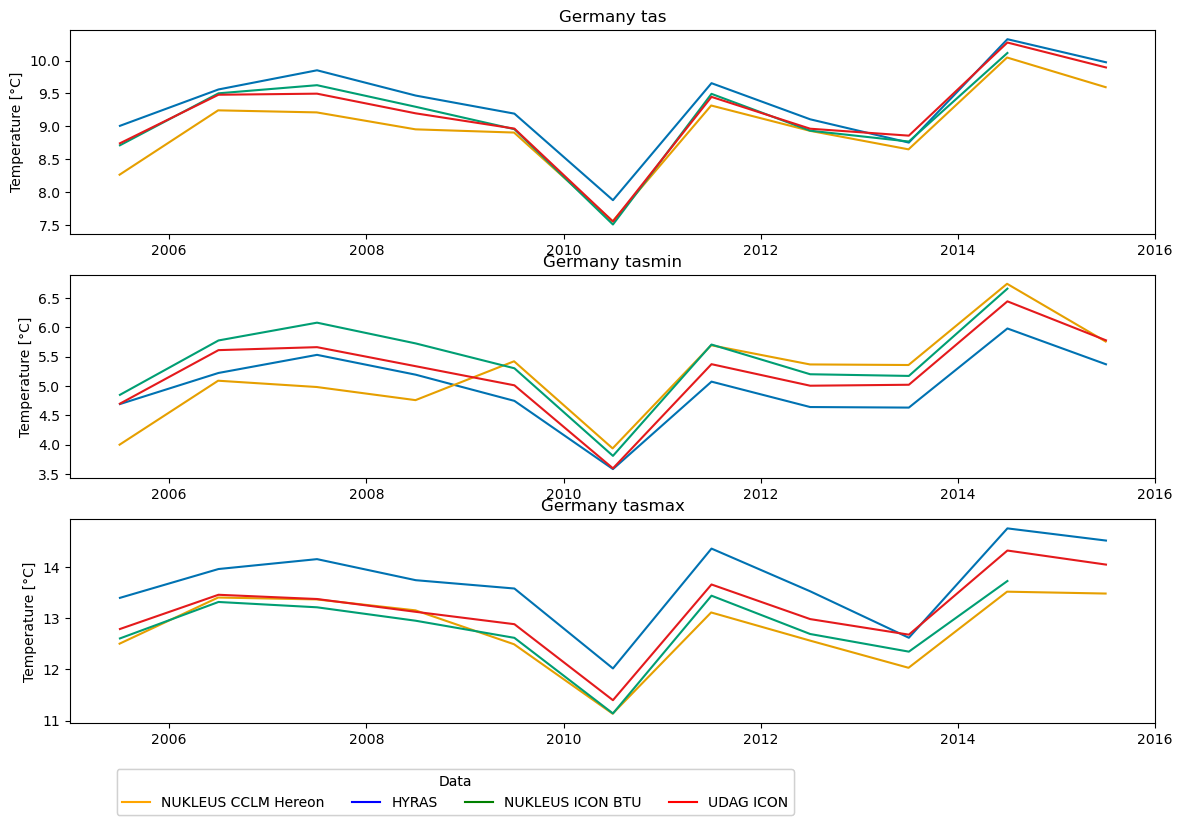

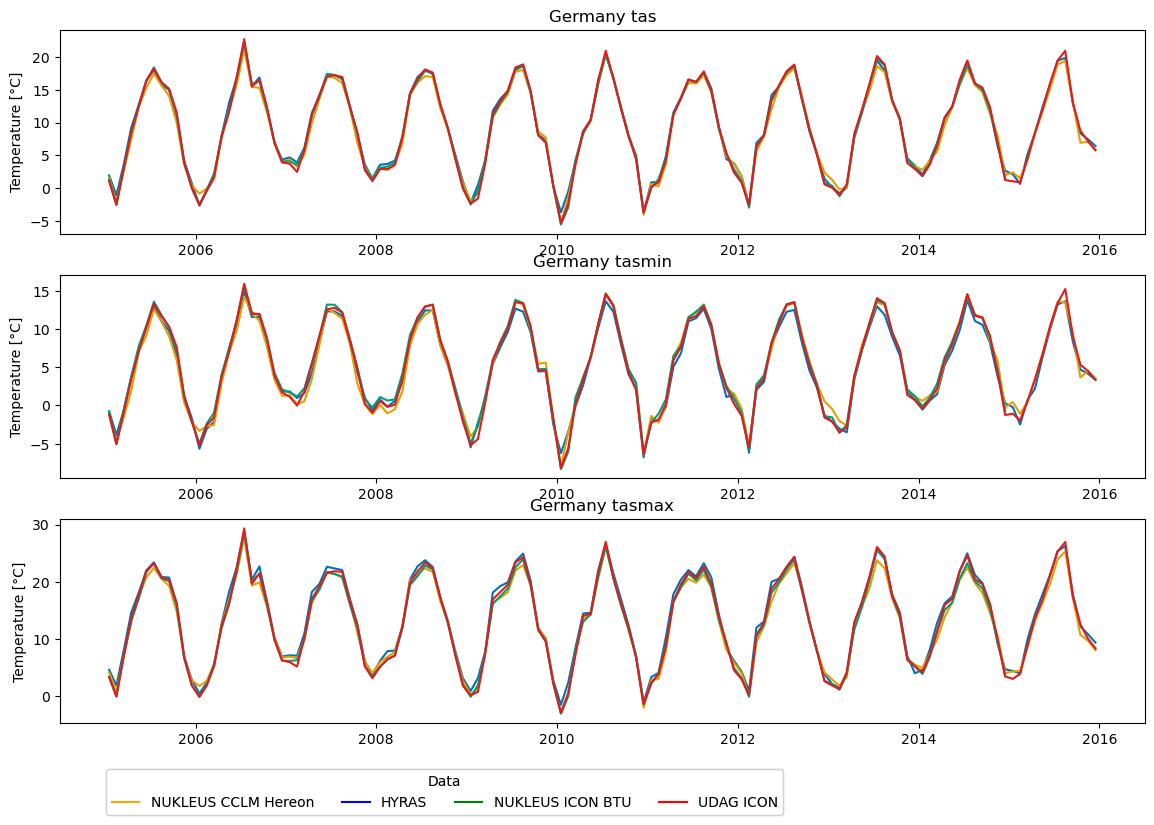

In [2]:
import json

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name}")
    with xr.open_dataset(hyras_path) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]),
            linestyle="solid",
            color=TOL_COLORS["blue"],
        )

    with xr.open_dataset(nukleus_hereon) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name] - 273.15),
            linestyle="solid",
            color=TOL_COLORS["orange"],
        )
    with xr.open_dataset(nukleus_btu) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name] - 273.15),
            linestyle="solid",
            color=TOL_COLORS["green"],
        )

    with xr.open_dataset(udag_eval) as df:
        df = df.sel(time=slice("2005", "2015"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[list(df.keys())[1]] - 273.15),
            linestyle="solid",
            color=TOL_COLORS["red"],
        )
    ax.set_ylabel("Temperature [°C]")


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "tas": load_json_file(f"{base_path}/NUKLEUS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmax_info.json"),
    },
    "HYRAS": {
        "tas": load_json_file(f"{base_path}/HYRAS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/HYRAS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/HYRAS_Germany_tasmax_info.json"),
    },
    "UDAG": {
        "tas": load_json_file(f"{base_path}/UDAG_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/UDAG_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/UDAG_Germany_tasmax_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(3, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes[0],
        files["HYRAS"]["tas"][freq],
        files["NUKLEUS"]["tas"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tas"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tas"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tas",
    )

    plot_variable(
        axes[1],
        files["HYRAS"]["tasmin"][freq],
        files["NUKLEUS"]["tasmin"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tasmin"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tasmin"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tasmin",
    )

    plot_variable(
        axes[2],
        files["HYRAS"]["tasmax"][freq],
        files["NUKLEUS"]["tasmax"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tasmax"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tasmax"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tasmax",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "HYRAS": "blue",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/EVAL_HYRAS_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


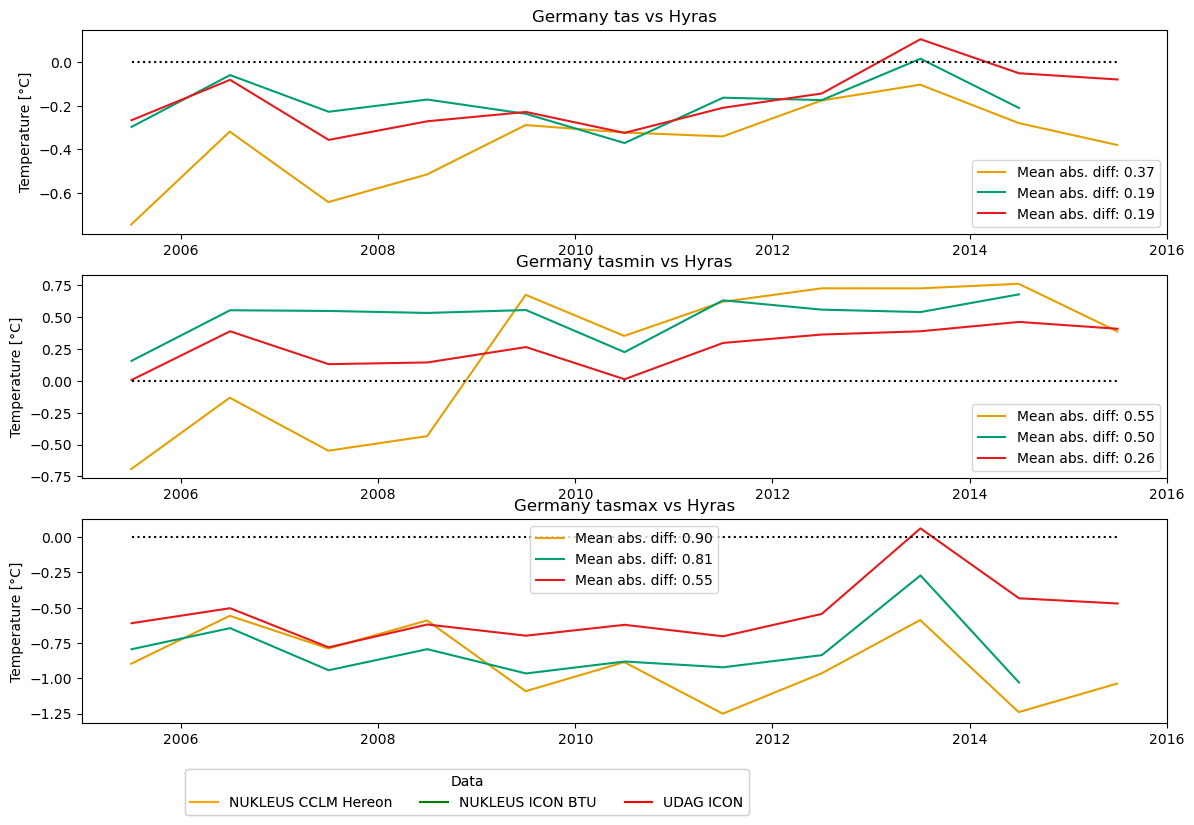

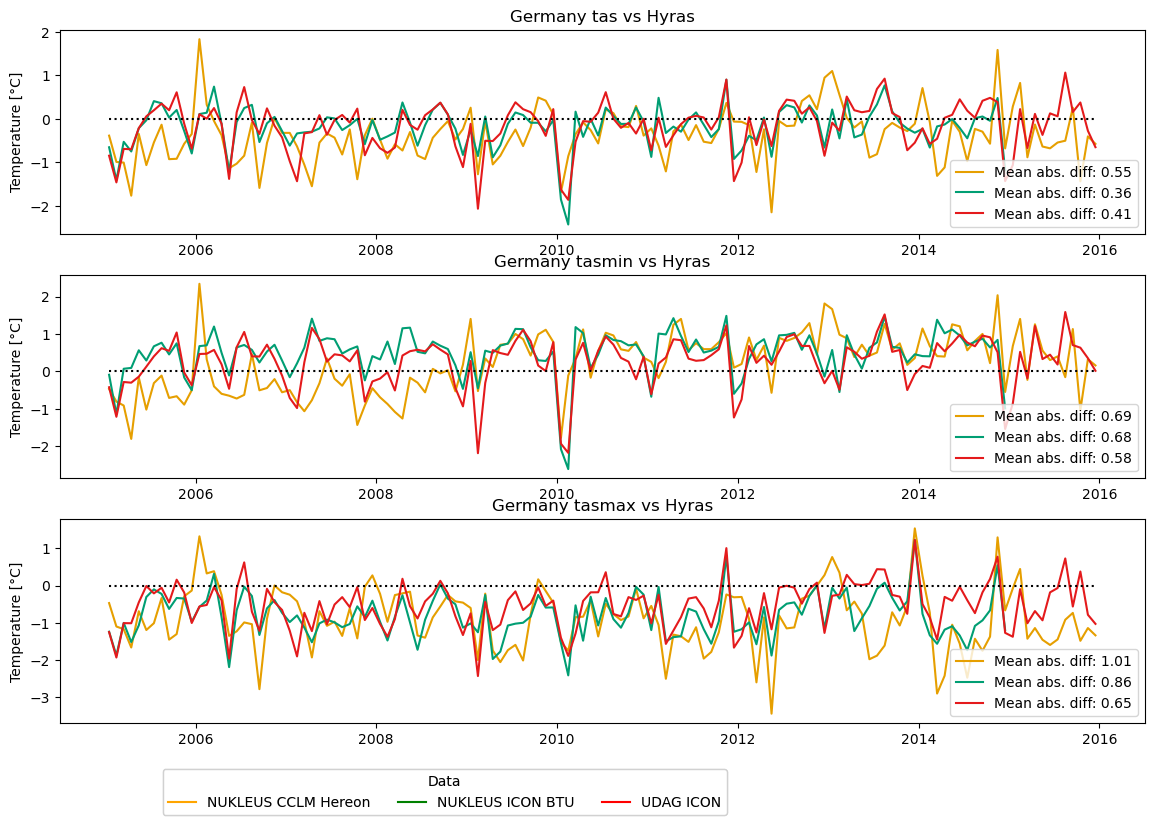

In [3]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name} vs Hyras")
    with xr.open_dataset(hyras_path) as dx:
        with xr.open_dataset(nukleus_hereon) as df:
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
            )
            ax.plot(
                np.squeeze(df["time"]),
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
                linestyle="solid",
                color=TOL_COLORS["orange"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(nukleus_btu) as df:
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
            )
            ax.plot(
                np.squeeze(dx["time"][0 : len(np.squeeze(df[var_name].values))]),
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
                linestyle="solid",
                color=TOL_COLORS["green"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2015"))
            diff = np.squeeze(df[list(df.keys())[1]].values - 273.15) - np.squeeze(
                dx[var_name].values
            )
            ax.plot(
                np.squeeze(df["time"]),
                diff,
                linestyle="solid",
                color=TOL_COLORS["red"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
            ax.plot(df["time"], [0] * len(df["time"]), linestyle=":", color="black")
    ax.set_ylabel("Temperature [°C]")
    ax.legend()


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "tas": load_json_file(f"{base_path}/NUKLEUS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmax_info.json"),
    },
    "HYRAS": {
        "tas": load_json_file(f"{base_path}/HYRAS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/HYRAS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/HYRAS_Germany_tasmax_info.json"),
    },
    "UDAG": {
        "tas": load_json_file(f"{base_path}/UDAG_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/UDAG_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/UDAG_Germany_tasmax_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(3, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes[0],
        files["HYRAS"]["tas"][freq],
        files["NUKLEUS"]["tas"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tas"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tas"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tas",
    )

    plot_variable(
        axes[1],
        files["HYRAS"]["tasmin"][freq],
        files["NUKLEUS"]["tasmin"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tasmin"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tasmin"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tasmin",
    )

    plot_variable(
        axes[2],
        files["HYRAS"]["tasmax"][freq],
        files["NUKLEUS"]["tasmax"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["tasmax"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["tasmax"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "tasmax",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/Diff_EVAL_HYRAS_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


In [4]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def mean_abs_diff(hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq):
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
            )
            print(
                f"Mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
            )
            print(
                f"Mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = np.squeeze(df[list(df.keys())[1]].values - 273.15) - np.squeeze(
                dx[var_name].values
            )
            print(f"Mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}")


def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


def three_day_mean_abs_diff(
    hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq
):
    freq = "3 day mean"
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values - 273.15), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values - 273.15), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = moving_average(
                np.squeeze(df[list(df.keys())[1]].values - 273.15), 3
            ) - moving_average(np.squeeze(dx[var_name].values), 3)
            print(
                f"Moving mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "tas": load_json_file(f"{base_path}/NUKLEUS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmax_info.json"),
    },
    "HYRAS": {
        "tas": load_json_file(f"{base_path}/HYRAS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/HYRAS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/HYRAS_Germany_tasmax_info.json"),
    },
    "UDAG": {
        "tas": load_json_file(f"{base_path}/UDAG_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/UDAG_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/UDAG_Germany_tasmax_info.json"),
    },
}

for variable in ["tas", "tasmin", "tasmax"]:
    for freq in ["yearly", "mon", "day"]:
        mean_abs_diff(
            files["HYRAS"][variable][freq],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
            files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
            variable,
            freq,
        )

    three_day_mean_abs_diff(
        files["HYRAS"][variable][freq],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        variable,
        "day",
    )

Mean abs. diff Nukleus Hereon tas yearly: 0.37
Mean abs. diff Nukleus BTU tas yearly: 0.19
Mean abs. diff UDAG tas yearly: 0.20
Mean abs. diff Nukleus Hereon tas mon: 0.55
Mean abs. diff Nukleus BTU tas mon: 0.36
Mean abs. diff UDAG tas mon: 0.41
Mean abs. diff Nukleus Hereon tas day: 1.04
Mean abs. diff Nukleus BTU tas day: 0.74


Mean abs. diff UDAG tas day: 0.79
Moving mean abs. diff Nukleus Hereon tas 3 day mean: 0.90
Moving mean abs. diff Nukleus BTU tas 3 day mean: 0.63
Moving mean abs. diff UDAG tas 3 day mean: 0.69
Mean abs. diff Nukleus Hereon tasmin yearly: 0.57
Mean abs. diff Nukleus BTU tasmin yearly: 0.50
Mean abs. diff UDAG tasmin yearly: 0.25
Mean abs. diff Nukleus Hereon tasmin mon: 0.69
Mean abs. diff Nukleus BTU tasmin mon: 0.68
Mean abs. diff UDAG tasmin mon: 0.58
Mean abs. diff Nukleus Hereon tasmin day: 1.26
Mean abs. diff Nukleus BTU tasmin day: 1.03
Mean abs. diff UDAG tasmin day: 0.99
Moving mean abs. diff Nukleus Hereon tasmin 3 day mean: 1.10
Moving mean abs. diff Nukleus BTU tasmin 3 day mean: 0.91
Moving mean abs. diff UDAG tasmin 3 day mean: 0.86
Mean abs. diff Nukleus Hereon tasmax yearly: 0.89
Mean abs. diff Nukleus BTU tasmax yearly: 0.81
Mean abs. diff UDAG tasmax yearly: 0.56
Mean abs. diff Nukleus Hereon tasmax mon: 1.00
Mean abs. diff Nukleus BTU tasmax mon: 0.86
Mean abs. diff

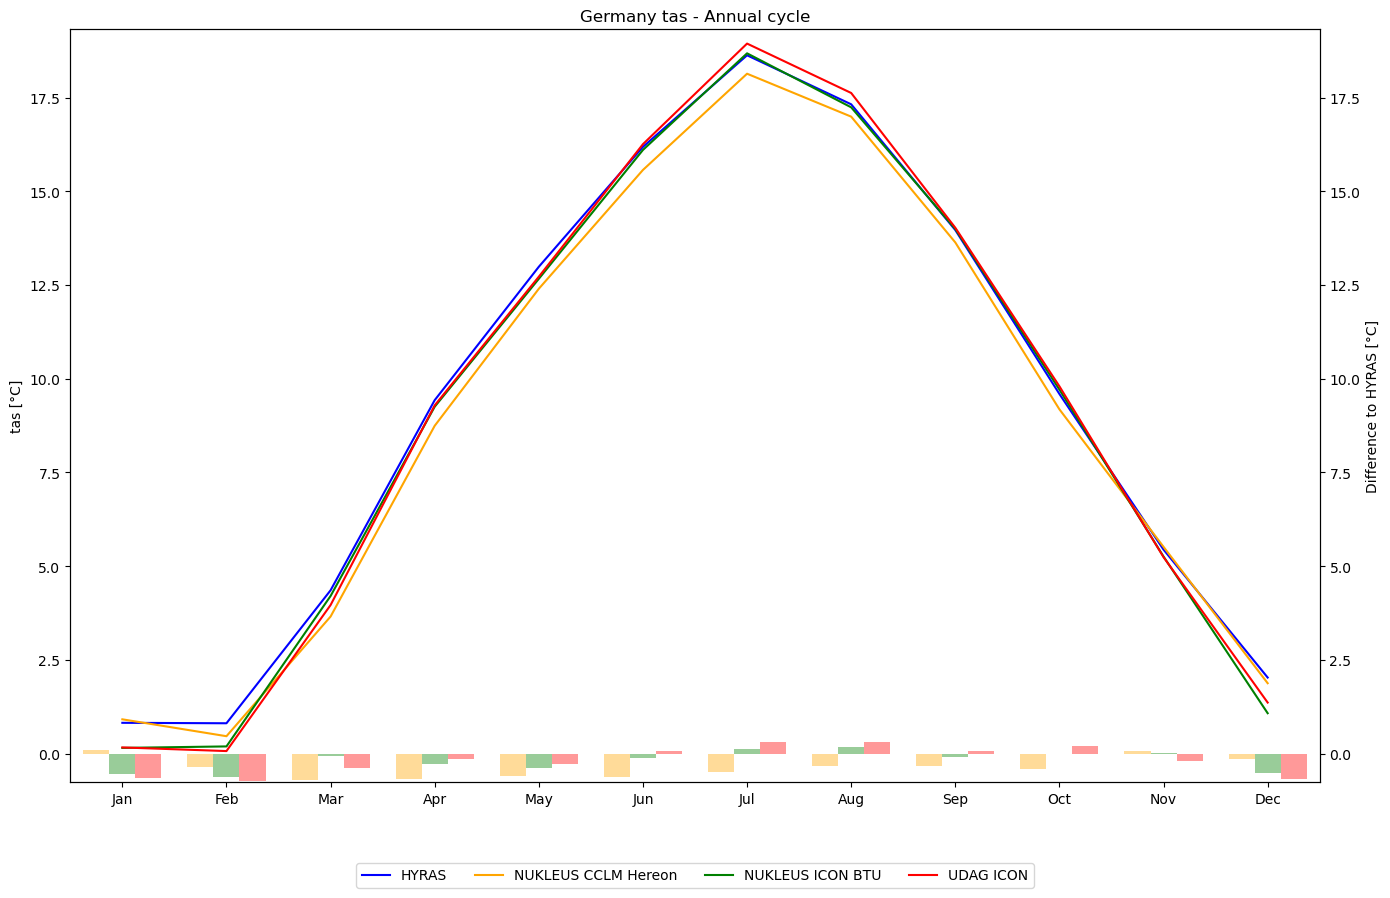

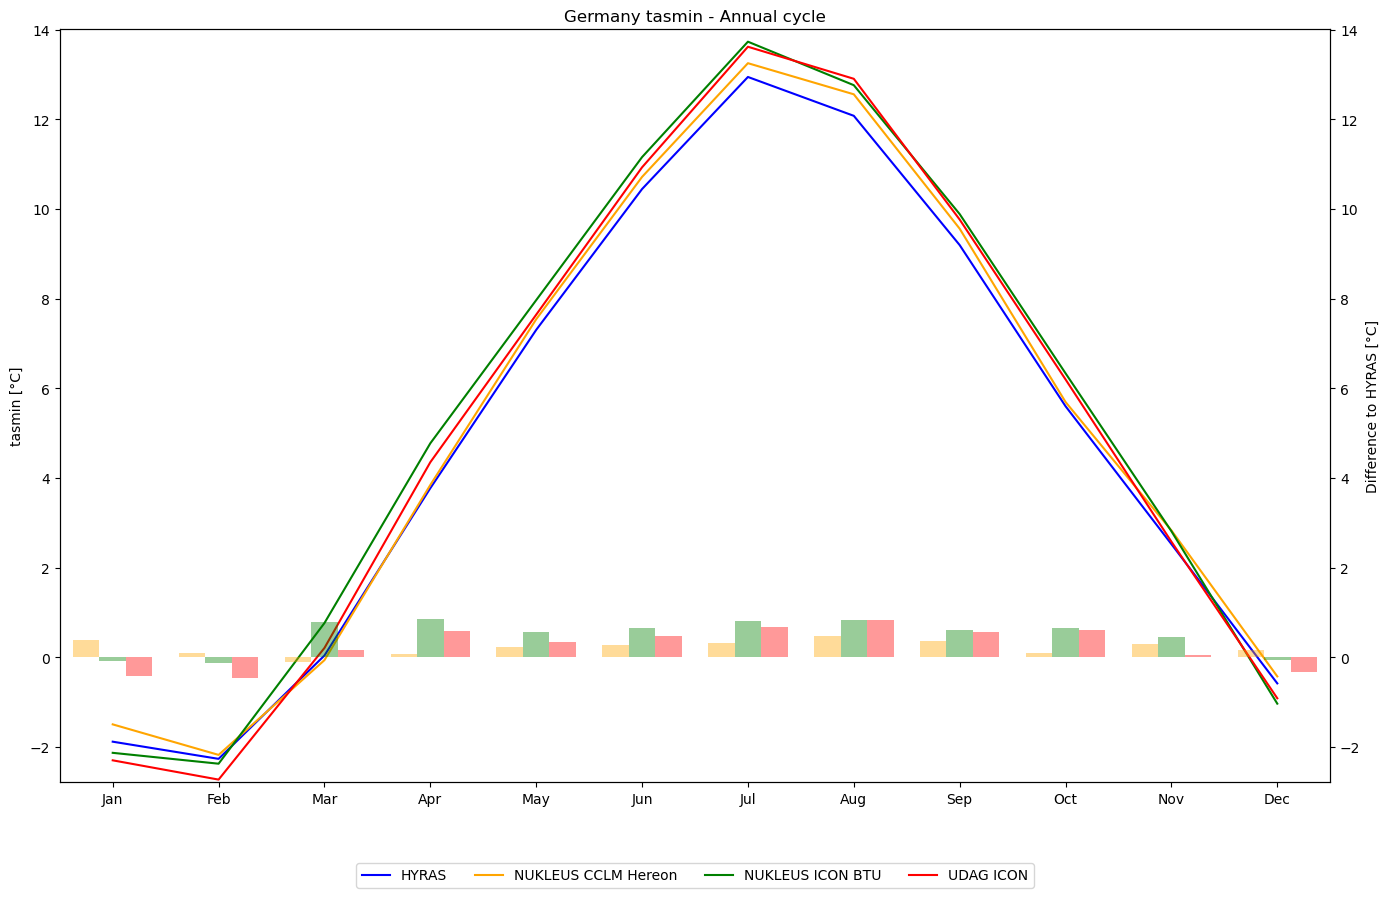

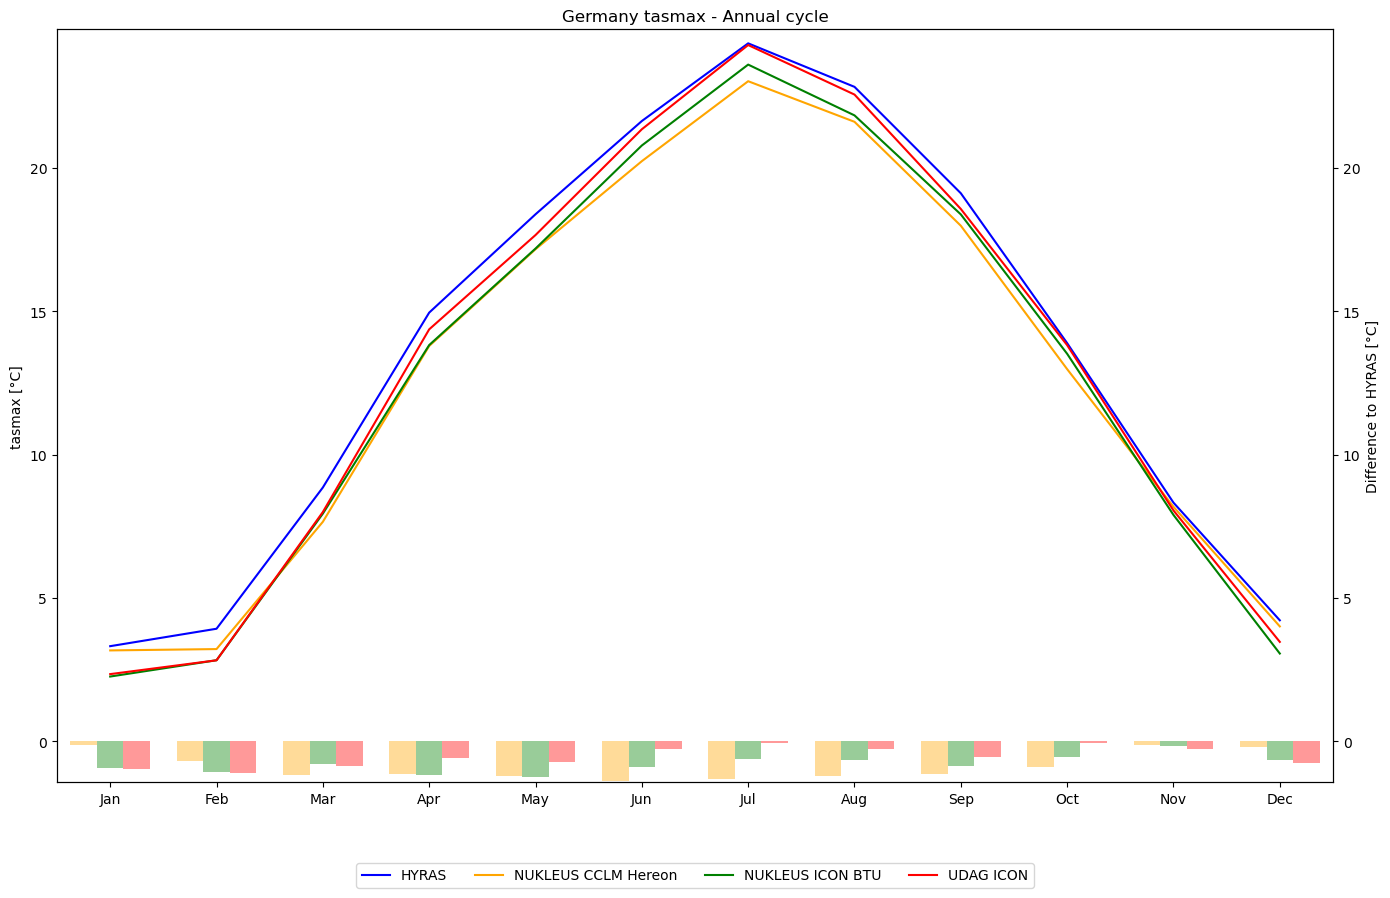

In [ ]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def monthly_mean(ds, var):
    return ds[var].groupby("time.month").mean()


# ---------------------------------------------------------
# File loading
# ---------------------------------------------------------

base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

for var_name in ["tas", "tasmin", "tasmax"]:
    files = {
        "NUKLEUS": {
            var_name: load_json_file(
                f"{base_path}/NUKLEUS_Germany_{var_name}_info.json"
            ),
        },
        "HYRAS": {
            var_name: load_json_file(f"{base_path}/HYRAS_Germany_{var_name}_info.json"),
        },
        "UDAG": {
            var_name: load_json_file(f"{base_path}/UDAG_Germany_{var_name}_info.json"),
        },
    }

    freq = "mon"

    # ---------------------------------------------------------
    # Dataset definitions
    # ---------------------------------------------------------

    datasets = {
        "NUKLEUS CCLM Hereon": files["NUKLEUS"][var_name][freq]["ERA5"]["evaluation"][
            "CEU-3"
        ][1],
        "NUKLEUS ICON BTU": files["NUKLEUS"][var_name][freq]["ERA5"]["evaluation"][
            "CEU-3"
        ][0],
        "UDAG ICON": files["UDAG"][var_name][freq]["ERA5"]["evaluation"]["MEU-3"][0],
    }

    colors = {
        "HYRAS": "blue",
        "NUKLEUS CCLM Hereon": "orange",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }

    # ---------------------------------------------------------
    # Time windows per dataset
    # ---------------------------------------------------------

    time_windows = {
        "NUKLEUS CCLM Hereon": ("2005", "2015"),
        "NUKLEUS ICON BTU": ("2005", "2014"),  # special case
        "UDAG ICON": ("2005", "2015"),
    }

    # ---------------------------------------------------------
    # Load HYRAS full (2005–2015) for plotting the HYRAS curve
    # ---------------------------------------------------------

    with xr.open_dataset(files["HYRAS"][var_name][freq]) as ds_hyras_full:
        ds_hyras_full = ds_hyras_full.sel(time=slice("2005", "2015"))
        hyras_monthly_full = monthly_mean(ds_hyras_full, var_name)

    # ---------------------------------------------------------
    # Load all model datasets and compute monthly means + differences
    # ---------------------------------------------------------

    monthly_means = {}
    monthly_diffs = {}

    for name, path in datasets.items():
        start, end = time_windows[name]

        # Load model dataset with its own time window
        with xr.open_dataset(path) as ds:
            ds = ds.sel(time=slice(start, end))
            ds[var_name] = ds[var_name] - 273.15
            monthly_means[name] = monthly_mean(ds, var_name)

        # Load matching HYRAS window for this dataset
        with xr.open_dataset(files["HYRAS"][var_name][freq]) as ds_hyras_local:
            ds_hyras_local = ds_hyras_local.sel(time=slice(start, end))
            hyras_monthly_local = monthly_mean(ds_hyras_local, var_name)

        # Compute difference (model - HYRAS) for the matching window
        diff = xr.DataArray(
            monthly_means[name].values - hyras_monthly_local.values,
            dims=hyras_monthly_local.dims,
            coords=hyras_monthly_local.coords,
        )
        monthly_diffs[name] = diff

    # ---------------------------------------------------------
    # Compute global min/max across all curves and bars
    # ---------------------------------------------------------

    all_monthly = [hyras_monthly_full] + list(monthly_means.values())
    all_diffs = list(monthly_diffs.values())

    min_value = xr.concat(all_monthly + all_diffs, dim="source").min().item()
    max_value = xr.concat(all_monthly + all_diffs, dim="source").max().item()

    # ---------------------------------------------------------
    # Plotting
    # ---------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 9))
    months = np.arange(1, 13)

    # HYRAS curve (always 2005–2015)
    ax.plot(months, hyras_monthly_full, color=colors["HYRAS"], label="HYRAS")

    # Model curves
    for name, monthly in monthly_means.items():
        ax.plot(months, monthly, color=colors[name], label=name)

    ax.set_ylabel(f"{var_name} [°C]")
    ax.set_title(f"Germany {var_name} - Annual cycle")
    ax.set_ylim(min_value * 1.02, max_value * 1.02)

    # Side-by-side bars for differences
    ax2 = ax.twinx()
    bw = 0.25  # bar width

    for i, (name, diff) in enumerate(monthly_diffs.items()):
        offset = (i - 1) * bw
        ax2.bar(months + offset, diff.values, width=bw, alpha=0.4, color=colors[name])

    ax2.set_ylim(min_value * 1.02, max_value * 1.02)
    ax2.set_ylabel("Difference to HYRAS [°C]")

    # Legend
    handles = [mlines.Line2D([], [], color=colors[k], label=k) for k in colors]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=4)

    # Month labels
    month_names = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]
    ax.set_xticks(np.arange(1, 13))
    ax.set_xticklabels(month_names)
    ax.set_xlim(0.5, 12.5)

    plt.tight_layout()
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/EVAL_HYRAS_{var_name}_AC_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()
